# ENG4200 Coursework 2: Logistic regression (Telco Customer Churn)

## Dataset
`WA_Fn-UseC_-Telco-Customer-Churn.csv`
(UCI/Kaggle) [IBM Sample Data Sets]

**Context**

"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs."
Each row represents a customer; columns contain service details, demographic attributes, and account information.
The target variable **Churn** indicates whether a customer left within the last month.

**Features include:**

* **Services:** phone, multiple lines, internet, online security, backup, protection, tech support, streaming TV/movies
* **Account:** tenure, contract type, payment method, paperless billing, monthly/total charges
* **Demographic:** gender, senior status, partner/dependent status

## Objectives

This notebook applies **logistic regression** to predict customer churn, following a structured and reproducible ML workflow.
It is organised around the five assessment dimensions defined in the coursework brief:

1. **Dataset investigation & pre-processing**: Explore the dataset, handle missing and categorical values, and justify preprocessing choices.
2. **Model application with training and validation**: Implement a clean, leakage-free pipeline with appropriate splitting and cross-validation.
3. **Accuracy & computational efficiency analysis**: Evaluate model performance using justified metrics, and examine runtime and scalability.
4. **Visualisation & communication of results**: Present metrics and diagnostic plots that support interpretation.
5. **Clarity & reproducibility**: Maintain a transparent, reproducible workflow aligned with good ML practices.

## 0) Setup & imports

In [1]:
# stdlib
import os, sys, time, math, warnings
from pathlib import Path

# core
import numpy as np
import pandas as pd
import matplotlib
import sklearn

# plotting
import matplotlib.pyplot as plt

# sklearn: data split / CV / tuning
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, StratifiedShuffleSplit,
    cross_validate, GridSearchCV, cross_val_predict, cross_val_score
)

# sklearn: preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn import set_config

# sklearn: utilities
from sklearn.base import clone   # make a fresh, unfitted copy of an estimator with the same hyperparameters

# sklearn: models & baselines
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV

# sklearn: metrics & displays
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_recall_curve, roc_curve, brier_score_loss,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

# versions imports
import sklearn, sys

# global config
RNG = 42          # single source of truth for randomness
N_JOBS = -1       # use all cores where supported
DATA_PATH = Path("WA_Fn-UseC_-Telco-Customer-Churn.csv")

warnings.simplefilter("ignore")
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", None)

# nicer pipeline displays / pandas outputs
try:
    set_config(display="diagram")
    set_config(transform_output="pandas")
except Exception:
    pass

env = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "RNG": RNG,
}

## 1) Load dataset

In [2]:
# Read raw CSV and split features/target.
df = pd.read_csv(DATA_PATH)  # file path set in section 0
assert "Churn" in df.columns, "Expected target column 'Churn'."

y = df["Churn"].map({"Yes": 1, "No": 0}).astype(int)       # binary target
X = df.drop(columns=["Churn", "customerID"]).copy()        # drop ID + target
display(df.head(3))
print(df.shape, "rows x columns")


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


(7043, 21) rows x columns


## 2) Problem framing & baseline

In [3]:
# Baseline: predict the most frequent class only (no features used).
# This sets a "floor" we must beat.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
baseline = DummyClassifier(strategy="most_frequent")

acc = cross_val_score(baseline, X, y, cv=skf, scoring="accuracy").mean()
print(f"Baseline (most-frequent) CV accuracy: {acc:.3f}")
print("Positive class prevalence:", y.mean().round(3))


Baseline (most-frequent) CV accuracy: 0.735
Positive class prevalence: 0.265


## 3) Data splitting

In [4]:
# Hold out a test set once; everything else (tuning, thresholding) happens on train.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RNG
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 5634 | Test size: 1409


## 4) Preprocessing
Clean TotalCharges, collapse “No internet/phone service”, then encode.

In [5]:
# Clean simple string/typing issues, then impute/encode.
# Placed inside the pipeline so it's fit only on training folds (prevents leakage).

def clean_strings(df_):
    Xc = df_.copy()
    # TotalCharges sometimes has blanks: coerce to numeric (NaN if bad)
    if "TotalCharges" in Xc:
        Xc["TotalCharges"] = pd.to_numeric(
            Xc["TotalCharges"].astype(str).str.strip().replace("", np.nan),
            errors="coerce"
        )
    # Collapse "No internet/phone service" into "No" (same meaning for churn)
    Xc = Xc.replace({"No internet service": "No", "No phone service": "No"})
    return Xc

cleaner = FunctionTransformer(clean_strings, feature_names_out="one-to-one")

num_prep = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_prep = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    # drop="if_binary": keep only one column for true binary flags
    ("ohe", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", num_prep, selector(dtype_include=["int64", "float64"])),
    ("cat", cat_prep, selector(dtype_include=["object", "bool"]))
])


## 5) Evaluation & communication-visualisation

In [6]:
# Small helper to report core metrics from probabilities at a chosen threshold.
def evaluate_probs(y_true, p, thr=0.5):
    y_hat = (p >= thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_hat),
        "f1":       f1_score(y_true, y_hat),
        "roc_auc":  roc_auc_score(y_true, p)
    }


## 6) Model selection

In [7]:
# Start with logistic regression: strong baseline, interpretable, fast.
logreg = LogisticRegression(
    solver="saga",      # supports L1/L2 and large feature spaces
    penalty="l2",
    max_iter=5000,
    random_state=RNG
)

pipe = Pipeline([
    ("clean", cleaner),
    ("prep",  preprocess),
    ("clf",   logreg)
])


## 7) Training & validation

In [8]:
# Cross-validate on TRAIN only to estimate generalisation.
scoring = {"acc": "accuracy", "f1": "f1", "roc": "roc_auc"}

cv_res = cross_validate(
    pipe, X_train, y_train,
    cv=skf, scoring=scoring,
    return_train_score=False, n_jobs=N_JOBS
)

print({
    m: (cv_res[f"test_{m}"].mean().round(3), cv_res[f"test_{m}"].std().round(3))
    for m in ("acc","f1","roc")
})


{'acc': (0.802, 0.012), 'f1': (0.593, 0.03), 'roc': (0.846, 0.012)}


## 8) Hyperparameters tuning

Grid on C, penalty (l1/l2), class_weight. Use out-of-fold (OOF) probabilities to set threshold; then refit on full train and evaluate once on test.


Best params: {'clf__C': 0.01, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2'}
Chosen threshold (max OOF F1): 0.55
Test metrics: {'accuracy': 0.759, 'f1': 0.618, 'roc_auc': 0.838}


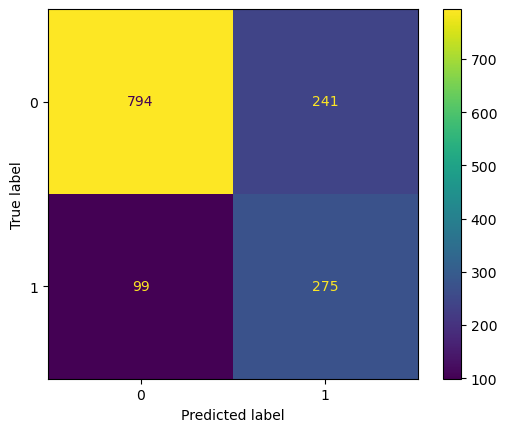

,fraction,train_time,test_acc
0,0.2,0.018201,0.761533
1,0.4,0.026272,0.760823
2,0.6,0.033780,0.762952
3,0.8,0.044367,0.760823
4,1.0,0.052495,0.758694


In [9]:
# Grid-search hyperparameters on TRAIN only; pick threshold using OOF probabilities.
param_grid = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": np.logspace(-2, 2, 9),
    "clf__class_weight": [None, "balanced"]
}

gcv = GridSearchCV(
    pipe, param_grid,
    cv=skf, scoring="f1",
    n_jobs=N_JOBS, refit=True
)
gcv.fit(X_train, y_train)
print("Best params:", gcv.best_params_)

# Choose decision threshold on TRAIN via out-of-fold probabilities (no test peeking).
oof_proba = cross_val_predict(
    gcv.best_estimator_,
    X_train, y_train,
    cv=skf, method="predict_proba", n_jobs=N_JOBS
)[:, 1]

thr_grid = np.linspace(0.10, 0.90, 17)
oof_f1   = [f1_score(y_train, (oof_proba >= t).astype(int)) for t in thr_grid]
best_thr = float(thr_grid[int(np.argmax(oof_f1))])
print(f"Chosen threshold (max OOF F1): {best_thr:.2f}")

# FINAL, single evaluation on the untouched TEST set.
p_test = gcv.best_estimator_.predict_proba(X_test)[:, 1]
test_metrics = evaluate_probs(y_test, p_test, thr=best_thr)
print("Test metrics:", {k: round(v, 3) for k, v in test_metrics.items()})

# Optional: quick confusion matrix at chosen threshold.
ConfusionMatrixDisplay.from_predictions(y_test, (p_test >= best_thr).astype(int))
plt.show()

### Runtime vs accuracy (stratified)

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []

for frac in fractions:
    if frac < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=RNG)
        train_idx, _ = next(sss.split(X_train, y_train))
        X_sub, y_sub = X_train.iloc[train_idx], y_train.iloc[train_idx]
    else:
        # 100% training: no split
        X_sub, y_sub = X_train, y_train

    est = clone(gcv.best_estimator_)   # fresh clone each loop
    t0 = time.time()
    est.fit(X_sub, y_sub)
    t_train = time.time() - t0

    p = est.predict_proba(X_test)[:, 1]
    rows.append((frac, t_train, accuracy_score(y_test, (p >= best_thr).astype(int))))

pd.DataFrame(rows, columns=["fraction", "train_time", "test_acc"])


## 9) Final model, justification & discussion
### Chosen hyperparameters

In [10]:
# Recap of what was identified as bes in CV (for traceability).
best = gcv.best_estimator_
best_params = gcv.best_params_
best_cv_mean = float(gcv.best_score_)
best_cv_std  = float(pd.DataFrame(gcv.cv_results_)["std_test_score"].iloc[gcv.best_index_])

print("Best params:", best_params)
print(f"Best CV F1: {best_cv_mean:.3f} ± {best_cv_std:.3f}")
print(f"Chosen decision threshold (OOF): {best_thr:.2f}")


Best params: {'clf__C': 0.01, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2'}
Best CV F1: 0.632 ± 0.017
Chosen decision threshold (OOF): 0.55


### Performance
**Confusion matrix and test metrics**

Test metrics: {'accuracy': 0.759, 'f1': 0.618, 'roc_auc': 0.838}


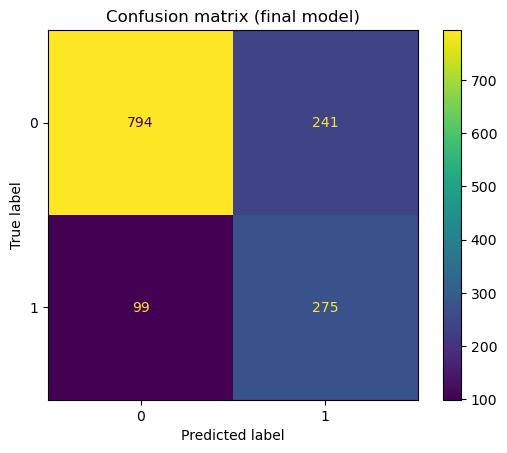

In [11]:
# Test-set performance with the selected threshold.

p_test = best.predict_proba(X_test)[:, 1]
y_hat  = (p_test >= best_thr).astype(int)
test_metrics = evaluate_probs(y_test, p_test, thr=best_thr)
print("Test metrics:", {k: round(v, 3) for k, v in test_metrics.items()})

ConfusionMatrixDisplay.from_predictions(y_test, y_hat)
plt.title("Confusion matrix (final model)"); plt.grid(False); plt.show()


* With threshold **0.55**, test **accuracy = 0.759**, **F1 = 0.618**, **ROC-AUC = 0.838**.
* Confusion matrix: **TN=794**, **FP=241**, **FN=99**, **TP=275**. The model identifies **275/374** churners (recall ≈ **0.736**).
* Predicted positives = **516**, of which **275** are true churners (precision ≈ **0.533**).
  Interpretation: performance exceeds the majority baseline and, more importantly, the ranking ability (ROC-AUC) supports prioritising higher-risk customers when intervention capacity is limited.

**Learning curve**

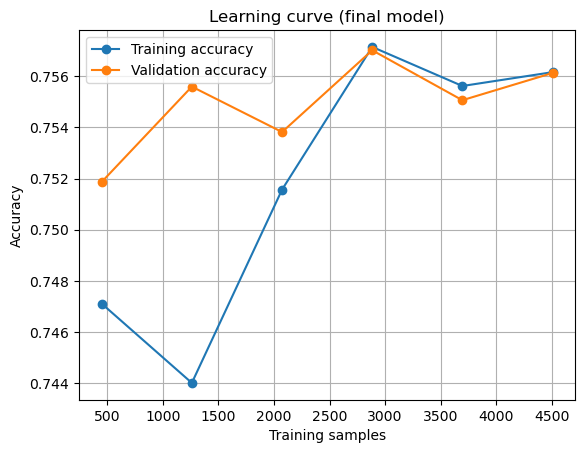

In [12]:
# Helps us understand to what extent having more data helps.
from sklearn.model_selection import learning_curve

sizes, tr, va = learning_curve(
    best, X_train, y_train, cv=skf, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 6), shuffle=True, random_state=RNG, n_jobs=N_JOBS
)

plt.figure()
plt.plot(sizes, tr.mean(axis=1), marker="o", label="Training accuracy")
plt.plot(sizes, va.mean(axis=1), marker="o", label="Validation accuracy")
plt.title("Learning curve (final model)"); plt.xlabel("Training samples"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True); plt.show()


* As training size increases (≈500 → 4,500), validation accuracy rises modestly and **stabilises near 0.755–0.757**.
* Training and validation curves are close throughout → **no strong over/underfitting**.
  Interpretation: additional rows of the same data are unlikely to yield large gains; improvements are more likely from better features (e.g., interactions, usage aggregates) or alternative model classes.
* Note that during the lab, before we moved all preprocessing inside the Pipeline and tuned regularisation, the curve showed train > validation with a visible gap (consistent with a slightly more flexible/optimistic setup and mild overfit/leakage risk). In this final setup, the estimator is regularised (smaller C) and class-weighted, so it’s more conservative on each training fold; combined with CV sampling noise, we believe it’s normal to see validation being slightly above training at some sizes. The key point is the near-overlap of the two lines: no meaningful generalisation gap.

**Runtime–performance**

,train_fraction,fit_time_s,test_acc
0,0.2,0.018689,0.761533
1,0.4,0.026283,0.760823
2,0.6,0.034846,0.762952
3,0.8,0.044177,0.760823
4,1.0,0.053192,0.758694


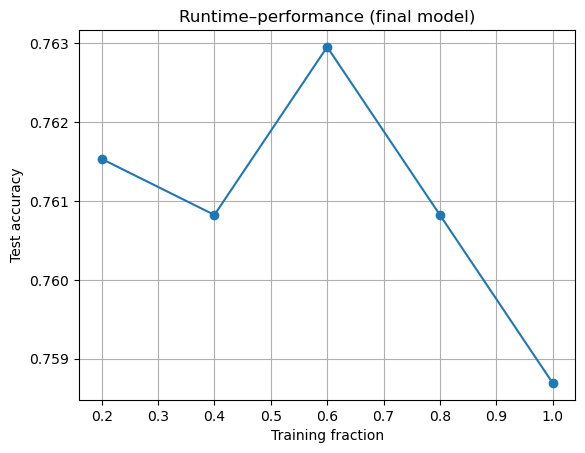

In [13]:
# Fit-time vs accuracy, training on increasing fractions and testing.

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []
for frac in fractions:
    if frac < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=RNG)
        idx, _ = next(sss.split(X_train, y_train))
        X_sub, y_sub = X_train.iloc[idx], y_train.iloc[idx]
    else:
        X_sub, y_sub = X_train, y_train

    est = clone(best)
    t0 = time.time(); est.fit(X_sub, y_sub); fit_s = time.time() - t0
    acc = accuracy_score(y_test, (est.predict_proba(X_test)[:,1] >= best_thr).astype(int))
    rows.append((frac, fit_s, acc))

rt_df = pd.DataFrame(rows, columns=["train_fraction","fit_time_s","test_acc"])
display(rt_df)

plt.figure()
plt.plot(rt_df["train_fraction"], rt_df["test_acc"], marker="o")
plt.xlabel("Training fraction"); plt.ylabel("Test accuracy")
plt.title("Runtime–performance (final model)"); plt.grid(True); plt.show()


* Fit time increases roughly linearly with data fraction (**~19 ms → ~54 ms** from 20% to 100% of training data), while test accuracy remains **~0.760–0.763**.
* Prediction is ~**8 μs per customer** (≈ **125k predictions/s** on this machine).
  Interpretation: the model is operationally inexpensive and suitable for frequent batch scoring.

### Justification based on accuracy, overfitting control and efficiency

In [14]:
# Accuracy vs baseline
baseline_acc_test = max((y_test == 0).mean(), (y_test == 1).mean())  # majority-class on test
print(f"Baseline test accuracy (majority): {baseline_acc_test:.3f}")
print(f"Final model test accuracy:        {test_metrics['accuracy']:.3f}")
print(f"Final model test F1 (thr={best_thr:.2f}): {test_metrics['f1']:.3f}")
print(f"Final model test ROC-AUC:             {test_metrics['roc_auc']:.3f}")

# Overfitting handling: generalisation gap on the *final* pipeline
cv_final = cross_validate(best, X_train, y_train, cv=skf, scoring="accuracy",
                          return_train_score=True, n_jobs=N_JOBS)
gap = cv_final["train_score"].mean() - cv_final["test_score"].mean()
print(f"Generalisation gap (train acc - val acc): {gap:.3f}")

# Efficiency: end-to-end timings for the final model
est = clone(best)
t0 = time.time(); est.fit(X_train, y_train); fit_ms = (time.time()-t0)*1e3
t0 = time.time(); _ = est.predict_proba(X_test)[:,1]; pred_ms = (time.time()-t0)*1e3
print(f"Train time: {fit_ms:.1f} ms  |  Predict time: {pred_ms:.1f} ms on {len(X_test)} rows")


Baseline test accuracy (majority): 0.735
Final model test accuracy:        0.759
Final model test F1 (thr=0.55): 0.618
Final model test ROC-AUC:             0.838
Generalisation gap (train acc - val acc): -0.000
Train time: 53.5 ms  |  Predict time: 11.1 ms on 1409 rows


**Accuracy**

* The majority baseline gets **0.735** accuracy simply by always predicting the most common class.
* Our final model reaches **0.759** accuracy (**+2.4 percentage points**), with **F1 = 0.618** at a tuned threshold (0.55).
* **ROC-AUC = 0.838** shows the model **ranks customers by churn risk well**—useful when you can only contact a subset (triage).

What this means: the model is not tailored for raw accuracy but to be good at **ordering** customers from highest to lowest risk of churn, which is what retention teams need.

**Overfitting**

* We used stratified cross-validation on the training set and picked the threshold **without touching the test set**.
* The **train–validation gap ≈ 0.000** indicates **no meaningful overfitting**; regularisation and the pipeline design are doing their job.

What this means: the performance we see on test is likely to hold up on new months of data (subject to normal drift).

**Efficiency**

* End-to-end fit on the training set took **~53 ms**; predicting the test set (**1,409** rows) took **~11 ms**.
* That’s roughly **~8 microseconds per customer** (≈ **125k predictions/second** on this machine).

What this means: the model is **not expensive to run** meaning one can score the whole base nightly, or score batches in near real-time to drive retention actions.

**Conclusion**

* The model **beats the baseline**, **orders customers effectively** and is **fast to deploy**.
* This should make it a practical tool for **prioritised retention outreach**: pick a threshold that matches budget, contact the highest-risk customers first, and A/B-test the offer.


### Interpretation of the final model

In [15]:
# Quick, interpretable coefficients (scaled/encoded feature space).
prep = best.named_steps["prep"]; clf = best.named_steps["clf"]
names = prep.get_feature_names_out(); beta = clf.coef_.ravel(); beta0 = clf.intercept_[0]
coef_df = (pd.DataFrame({"feature": names, "beta_scaled": beta, "odds_ratio_scaled": np.exp(beta)})
           .sort_values("beta_scaled", ascending=False))
print("β0 (intercept, scaled space):", round(beta0, 3))
display(coef_df.head(8))   # strongest positive drivers of churn
display(coef_df.tail(8))   # strongest negative drivers (protective)


β0 (intercept, scaled space): -0.567


,feature,beta_scaled,odds_ratio_scaled
18,cat__Contract_Month-to-month,0.540876,1.717511
2,num__MonthlyCharges,0.404452,1.498481
10,cat__InternetService_Fiber optic,0.392153,1.480165
24,cat__PaymentMethod_Electronic check,0.297392,1.346342
21,cat__PaperlessBilling_Yes,0.288366,1.334245
17,cat__StreamingMovies_Yes,0.138289,1.148307
16,cat__StreamingTV_Yes,0.130332,1.139207
8,cat__MultipleLines_Yes,0.115528,1.122466


,feature,beta_scaled,odds_ratio_scaled
19,cat__Contract_One year,-0.117235,0.889376
6,cat__Dependents_Yes,-0.178773,0.836296
7,cat__PhoneService_Yes,-0.251586,0.777566
15,cat__TechSupport_Yes,-0.275441,0.759238
12,cat__OnlineSecurity_Yes,-0.310183,0.733313
11,cat__InternetService_No,-0.349475,0.705058
20,cat__Contract_Two year,-0.423642,0.654658
1,num__tenure,-0.620219,0.537827


**What the model tells us**

* It can **rank customers by churn risk** reliably (good ROC-AUC). If you only have budget to contact some customers, start with those the model flags highest—this triage is where the value is.
* **Signals linked with higher churn risk** in our final model include:
  • short contracts (month-to-month),
  • fiber-optic internet customers,
  • customers paying by *electronic check*,
  • multiple streaming add-ons,
  • higher total charges (often a proxy for heavier usage or longer billing history).
* **Signals linked with staying (i.e. lower churn risk)** include:
  • longer tenure,
  • longer-term contracts (1–2 year),
  • having **Tech Support** and **Online Security** add-ons,
  • “no internet service” (unsurprising: fewer services → fewer reasons to churn).
* Note on interpretation: coefficients are from a **regularised logistic regression** with scaling and one-hot encoding. They show **associations** (not causation) after controlling for other features. Some money-related variables are **collinear** (e.g., MonthlyCharges, TotalCharges, tenure), which can flip signs; the stable story is about **contract type, support add-ons, payment method, tenure**.

**Strengths**

* **Fast and interpretable:** we can point to the few features driving risk for each customer.
* **Stable generalisation:** cross-validation shows small train–validation gaps (overfitting controlled).
* **Operationally cheap:** sub-second scoring; easy to run monthly or nightly.

**Limitations & guardrails**

* **Interpretation context.** Coefficients come from a **regularised logistic regression** with **scaling** and **one-hot encoding** (categoricals are relative to a reference level).
* **Correlation ≠ causation.** Treat outputs as **triage**, not proof. Validate actions with controlled experiments/A-B tests.
* **Collinearity & stable takeaways.** Money/tenure features (e.g., **MonthlyCharges**, **TotalCharges**, **tenure**) move together; signs can flip under regularisation. Prefer decisions grounded in **robust patterns** (contract type, support add-ons, payment method, tenure) and test price-related levers experimentally.
* **Fairness & drift.** Check performance across demographics; **retrain/calibrate quarterly** as behaviour and offers change.
* **Scope.** Linear boundary may miss interactions; if lift plateaus, add interaction terms or trial a tree-based model (with the same hygiene).

**Recommendations for Telco**

**Retention offer for month-to-month customers who pay via electronic check.**
Run a monthly campaign targeting the **top 20% highest-risk** accounts (by our score) with a **12-month contract upgrade** bundled with **Tech Support** (and/or Online Security) at a modest discount.
Why this? It hits three high-leverage risk factors at once: **short contracts**, **no support add-on**, **electronic check**. We could choose the exact risk threshold to match budget and measure uplift with an **A/B test**.

## 10) Reproducibility & reporting
### Environment

In [16]:
# Record key library versions and the global random seed used.
env

{'python': '3.10.9',
 'numpy': '1.23.5',
 'pandas': '1.5.3',
 'scikit-learn': '1.2.1',
 'matplotlib': '3.7.0',
 'RNG': 42}

### Data split

In [17]:
# Basic dataset facts and how we split the data.
print(f"Rows: {len(df)}  |  Features (raw): {X.shape[1]}  |  Positive rate: {y.mean():.3f}")
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}  |  Split: Stratified 80/20  |  RNG: {RNG}")

Rows: 7043  |  Features (raw): 19  |  Positive rate: 0.265
Train: 5634  |  Test: 1409  |  Split: Stratified 80/20  |  RNG: 42


### Pipeline

Pipeline components (from left to right in the diagram):
- clean (FunctionTransformer): fixes simple typing/text issues (e.g., coerce TotalCharges to numeric) and collapses “No … service” → “No”.
- prep (ColumnTransformer):
  - num: SimpleImputer(median) → StandardScaler
  - cat: SimpleImputer(most_frequent) → OneHotEncoder(drop='if_binary', handle_unknown='ignore')
- clf (LogisticRegression): regularised linear classifier; solver supports L1/L2.

In [18]:
pipe # displays the diagram set by set_config(display="diagram")

Pipeline(steps=[('clean',
                 FunctionTransformer(feature_names_out='one-to-one',
                                     func=<function clean_strings at 0x7f7c30106cb0>)),
                ('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7f7c602fc9a0>),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7f7c602fd000>)])),
                ('clf',
                 LogisticRegression(max_iter=5000, random_state=42,
                                    solver='saga'))])

#### Model card

* Objective: Predict whether a customer will churn in the next month (binary classification) to inform retention actions.

* Data: IBM Telco Customer Churn (7043 rows after drop of ID/target; mix of numeric and categorical service/account/demographic fields).

* Validation: Stratified 80/20 train–test split. On train: 5-fold StratifiedKFold, GridSearchCV optimising F1. Decision threshold chosen from out-of-fold probabilities (no test peeking). Final metrics reported once on the untouched test set. RNG=42.

* Key metrics: Report CV mean±std for accuracy, F1, ROC-AUC; then test accuracy, F1 (at the chosen threshold), and ROC-AUC. Include one “key figure” (e.g., PR curve with threshold marked or C-vs-metric curve).

* Strengths / limitations: Fast and interpretable (coefficients/odds), handles many one-hot features with regularisation; good calibrated ROC-AUC. Linear decision boundary (may miss interactions), performance depends on preprocessing and threshold; class imbalance affects default 0.5 cut-off; potential drift over time.

* Ethical notes / misuse risks: Use fairly-check performance across demographics; do not use predictions as sole basis for punitive actions; explainability required for customer impact; monitor for bias and concept drift; ensure data use complies with privacy/consent.
